# Customer Analytics & Churn Prediction

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Load Data

In [2]:
file_path = 'online_retail_II.xlsx'

# Read sheets
df1 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
df2 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

# Combine datasets
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Data inspection
print("Duplicate Rows Before Cleaning:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Duplicate Rows Before Cleaning: 34335

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


## Data Cleaning

In [4]:
# Standardize columns
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Remove duplicates
df = df.drop_duplicates()

# Remove missing customer IDs
df = df.dropna(subset=['Customer_ID'])

# Remove cancelled invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove invalid values
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Convert data types
df['Customer_ID'] = df['Customer_ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Create year-month column
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

print(df.shape)
df.head()

(779425, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [5]:
# Check duplicate rows after cleaning
print("Remaining Duplicate Rows:", df.duplicated().sum())

# Check missing values
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Remaining Duplicate Rows: 0

Missing Values After Cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
Revenue        0
YearMonth      0
dtype: int64


In [6]:
# Save cleaned data
df.to_csv('clean_online_retail.csv', index=False)

## Exploratory Data Analysis (EDA)

In [7]:
# KPI summary
print("Total Revenue:", round(df['Revenue'].sum(), 2))
print("Total Orders:", df['Invoice'].nunique())
print("Total Customers:", df['Customer_ID'].nunique())

aov = df.groupby('Invoice')['Revenue'].sum().mean()
print("Average Order Value (AOV):", round(aov, 2))

repeat_customer_rate = ((df.groupby('Customer_ID')['Invoice'].nunique() > 1).mean() * 100)
print("Repeat Customer Rate (%):", round(repeat_customer_rate, 2))

Total Revenue: 17374804.27
Total Orders: 36969
Total Customers: 5878
Average Order Value (AOV): 469.98
Repeat Customer Rate (%): 72.39


In [8]:
# Monthly revenue trend
monthly_rev = df.groupby('YearMonth', as_index=False)['Revenue'].sum()

fig = px.line(
    monthly_rev,
    x='YearMonth',
    y='Revenue',
    markers=True,
    title='Monthly Revenue Trend'
)

fig.show()

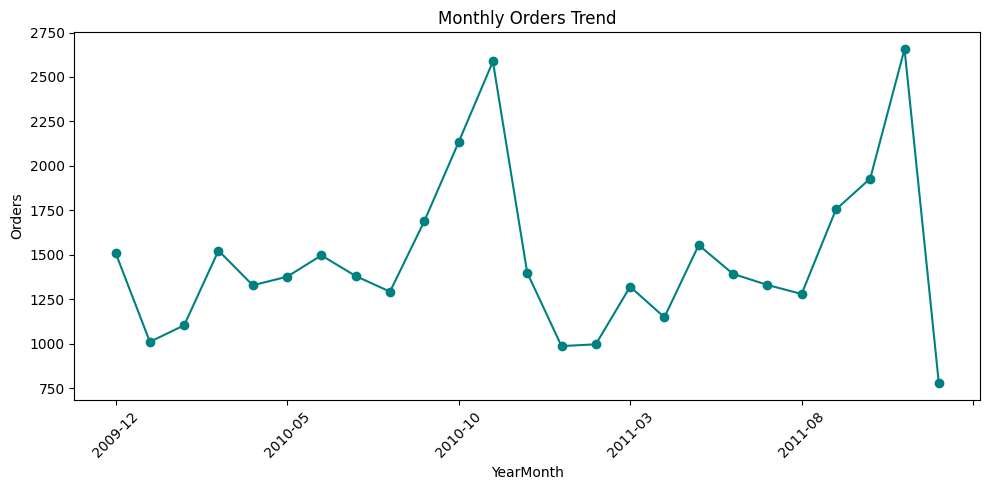

In [9]:
# Monthly orders trend
monthly_orders = df.groupby('YearMonth')['Invoice'].nunique()

plt.figure(figsize=(10,5))
monthly_orders.plot(marker='o', color='teal')
plt.title("Monthly Orders Trend")
plt.xlabel("YearMonth")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

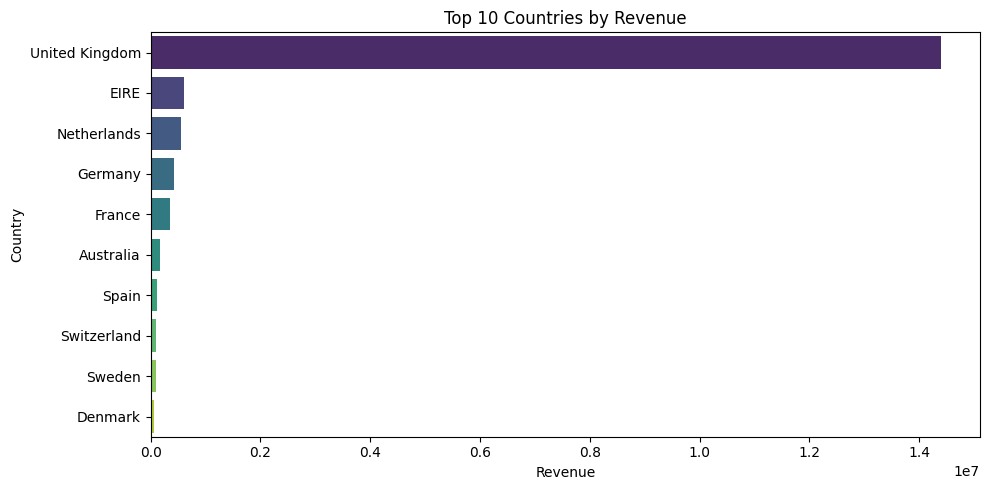

In [10]:
# Top 10 countries by revenue
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=country_rev.values,
    y=country_rev.index,
    hue=country_rev.index,
    palette='viridis',
    legend=False
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

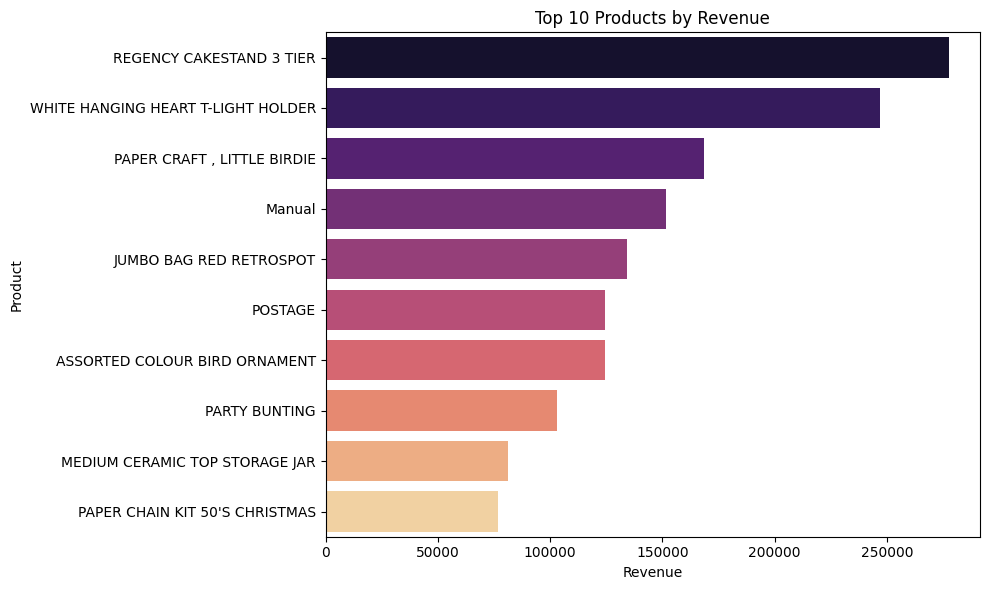

In [11]:
# Top 10 products by revenue
df['Description'] = df['Description'].str.strip()

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='magma',
    legend=False
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

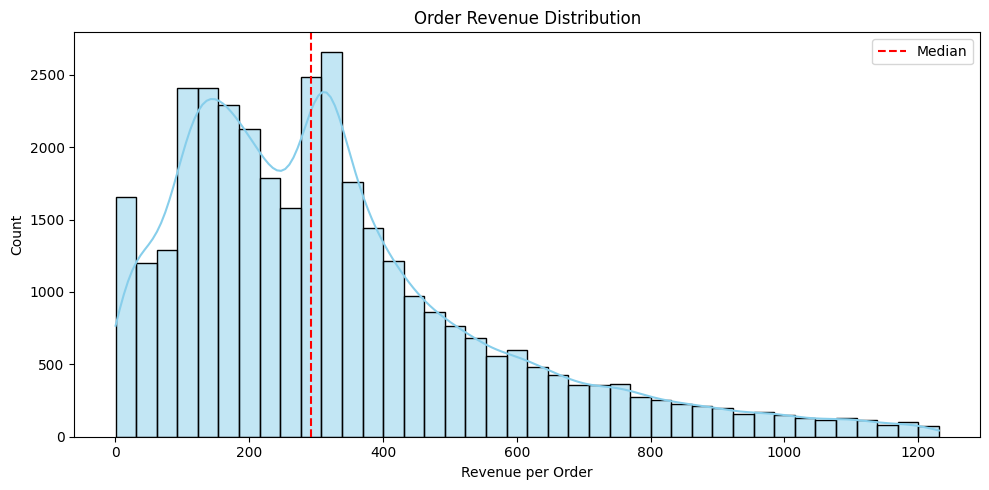

In [12]:
# Order revenue distribution
invoice_rev = df.groupby('Invoice')['Revenue'].sum()

filtered_orders = invoice_rev[invoice_rev <= invoice_rev.quantile(0.95)]

plt.figure(figsize=(10,5))

sns.histplot(
    filtered_orders,
    bins=40,
    kde=True,
    color='skyblue'
)

plt.axvline(
    filtered_orders.median(),
    color='red',
    linestyle='--',
    label='Median'
)

plt.title("Order Revenue Distribution")
plt.xlabel("Revenue per Order")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## RFM Analysis

RFM Table:
   Customer_ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   4921.53
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40

Segment Count:
Segment
Lost Customers         1526
Champions              1289
Potential Loyalists    1089
At Risk                 825
Loyal Customers         708
New Customers           441
Name: count, dtype: int64


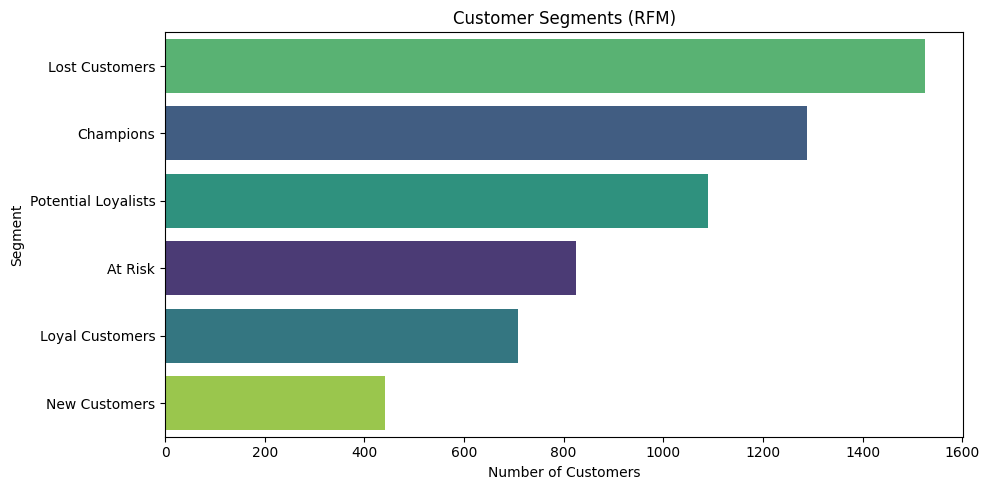

In [13]:
# Set reference date (one day after latest purchase)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Build RFM table
rfm = df.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print("RFM Table:")
print(rfm.head())

# Assign RFM scores (1 to 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Combine scores
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))

# Create customer segments
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

# Apply segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("\nSegment Count:")
print(rfm['Segment'].value_counts())

# Plot segments
plt.figure(figsize=(10, 5))

sns.countplot(
    y='Segment',
    data=rfm,
    order=rfm['Segment'].value_counts().index,
    hue='Segment',
    palette='viridis',
    legend=False
)

plt.title("Customer Segments (RFM)")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

## Customer Segmentation with KMeans

   k  silhouette_score
0  2          0.438602
1  3          0.347745
2  4          0.364971
3  5          0.342496
4  6          0.334796
5  7          0.306636
6  8          0.303315

Cluster Summary:
         Recency  Frequency  Monetary
Cluster                              
0          394.9        1.4     317.1
1           28.3        3.1     857.5
2           27.7       19.3   10731.2
3          230.1        5.1    1948.5

Cluster Count:
Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


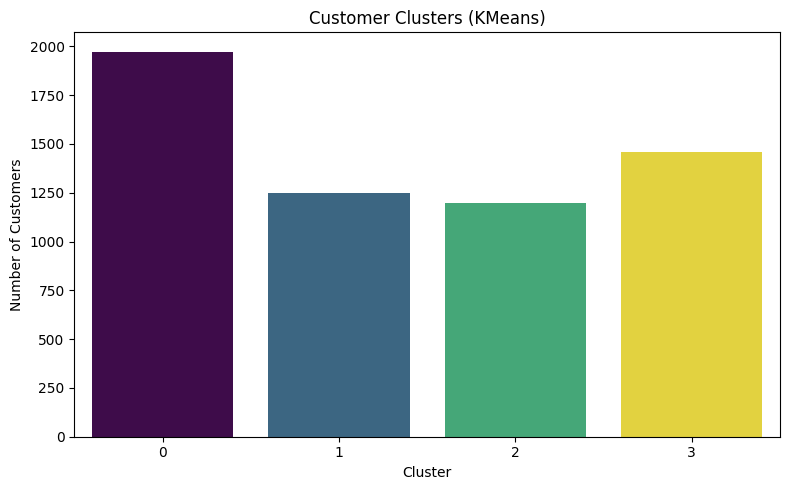

In [14]:
# Use RFM metrics
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Reduce skewness
X = np.log1p(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best number of clusters
scores = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append([k, score])

score_df = pd.DataFrame(scores, columns=['k', 'silhouette_score'])
print(score_df)

# Train final model with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster summary
print("\nCluster Summary:")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

print("\nCluster Count:")
print(rfm['Cluster'].value_counts().sort_index())

# Plot clusters
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=rfm,
    hue='Cluster',
    palette='viridis',
    legend=False
)

plt.title("Customer Clusters (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Cohort Retention Analysis

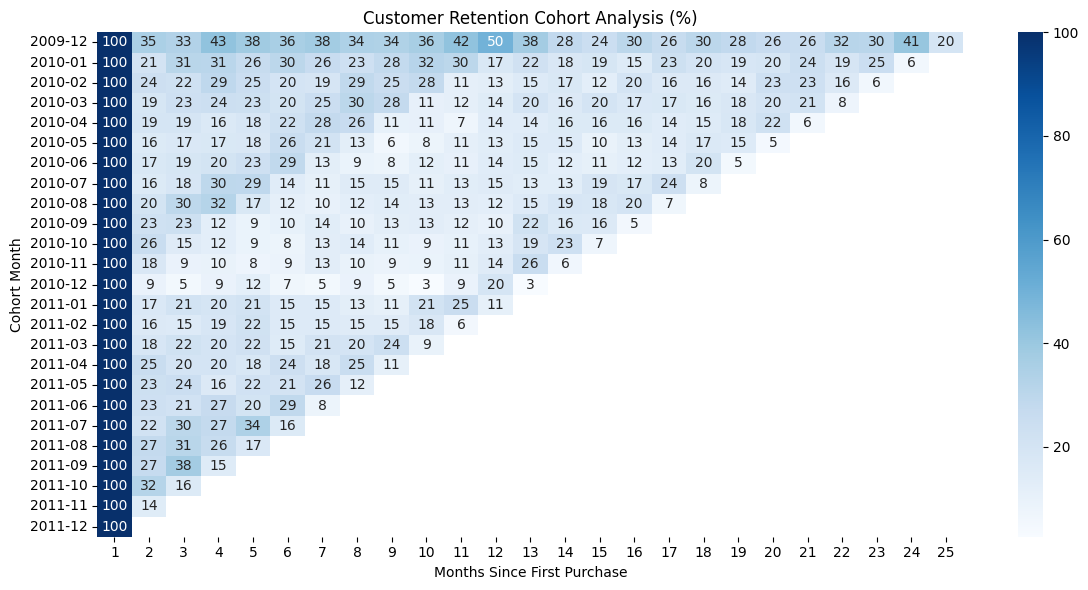

In [15]:
# Create purchase month and cohort month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('Customer_ID')['InvoiceMonth'].transform('min')

# Cohort index (months since first purchase)
df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month) + 1
)

# Count unique customers by cohort and month
cohort = df.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID'].nunique().reset_index()

# Create pivot table
cohort_pivot = cohort.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer_ID'
)

# Convert to retention %
retention = cohort_pivot.divide(cohort_pivot[1], axis=0) * 100

# Plot heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title("Customer Retention Cohort Analysis (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

## Churn Prediction

===== Logistic Regression =====
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       579
           1       0.79      0.83      0.81       597

    accuracy                           0.80      1176
   macro avg       0.80      0.80      0.80      1176
weighted avg       0.80      0.80      0.80      1176

ROC AUC Score: 0.864
Confusion Matrix:
[[443 136]
 [100 497]]

Logistic Coefficients:
Frequency       -4.972
Monetary        -0.362
AvgOrderValue   -0.078
Tenure           1.226
dtype: float64


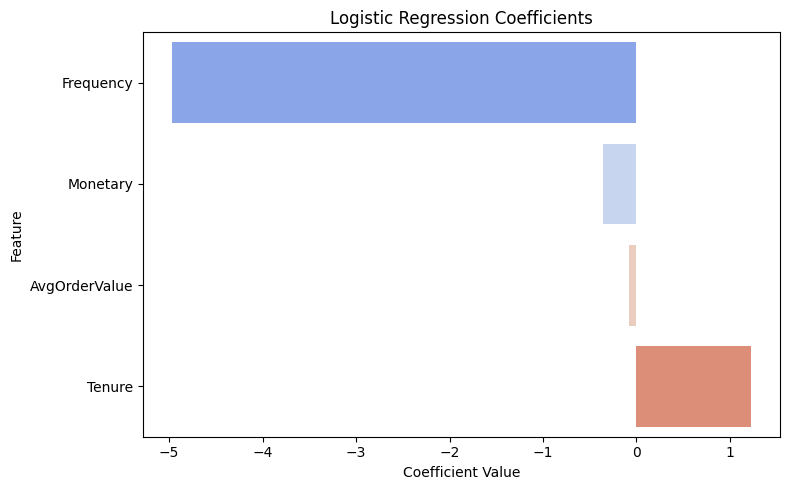


===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       579
           1       0.81      0.80      0.81       597

    accuracy                           0.81      1176
   macro avg       0.81      0.81      0.81      1176
weighted avg       0.81      0.81      0.81      1176

ROC AUC Score: 0.899
Confusion Matrix:
[[469 110]
 [118 479]]

Random Forest Feature Importance:
Tenure           0.405
Monetary         0.231
Frequency        0.206
AvgOrderValue    0.157
dtype: float64


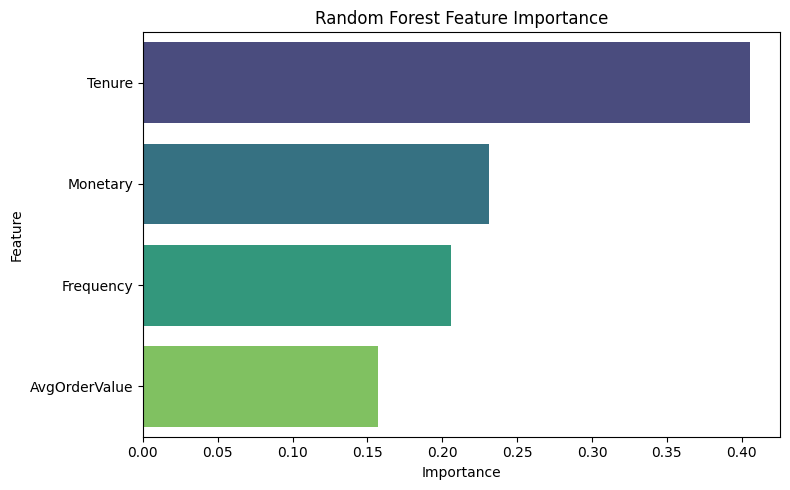


===== Model Comparison =====
                 Model   ROC_AUC
0  Logistic Regression  0.863891
1        Random Forest  0.899406


In [16]:
# Set reference date
snapshot_date = df['InvoiceDate'].max()

# Create customer-level summary
customer_data = df.groupby('Customer_ID').agg({
    'InvoiceDate': ['min', 'max'],
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename column names
customer_data.columns = ['FirstPurchase', 'LastPurchase', 'Frequency', 'Monetary']

# Create features
customer_data['Recency'] = (snapshot_date - customer_data['LastPurchase']).dt.days
customer_data['Tenure'] = (snapshot_date - customer_data['FirstPurchase']).dt.days
customer_data['AvgOrderValue'] = (customer_data['Monetary'] / customer_data['Frequency'])

# Define churn (customer inactive for more than 90 days)
customer_data['Churn'] = (customer_data['Recency'] > 90).astype(int)

# Prepare train/test data 
X = customer_data[['Frequency', 'Monetary', 'Tenure', 'AvgOrderValue']]
y = customer_data['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==================================
# Logistic Regression
# ==================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("===== Logistic Regression =====")
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

print("ROC AUC Score:", round(roc_auc_score(y_test, y_prob_log), 3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Coefficients
coef = pd.Series(log_model.coef_[0], index=X.columns).sort_values()

print("\nLogistic Coefficients:")
print(coef.round(3))

# Plot coefficients
plt.figure(figsize=(8,5))
sns.barplot(
    x=coef.values,
    y=coef.index,
    hue=coef.index,
    palette='coolwarm',
    legend=False
)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ==================================
# Random Forest
# ==================================
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n===== Random Forest =====")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Feature Importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance.round(3))

# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(
    x=importance.values,
    y=importance.index,
    hue=importance.index,
    palette='viridis',
    legend=False
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ==================================
# Model Comparison
# ==================================
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print("\n===== Model Comparison =====")
print(comparison)